# [0813] Part2_assignment

- 기수: 16기

- 이름: 조규홍

- 출제자: 15기 학술부(안재민, 이은민, 현승원)


### 과제 안내

본 과제는 Intro to DL, CNN, LLM Basic, LLM with Transformer 네 세션의 내용을 **직접 구현하며 복습**하는 것을 목표로 합니다.

제목에 `[TODO]` 가 붙은 부분을 채워 넣으면 됩니다. 코드 셀은 `# TODO` 주석 자리를, 마크다운 셀은 서술형 답을 채우면 됩니다.

**준비물** — 배포된 zip을 풀면 아래 구조가 나옵니다. 이대로 두시면 됩니다.

```
[0813]Part2_이름/
├── [0813]Part2_이름.ipynb
├── conv_utils.py
├── cat.jpeg
├── cat_64.png
└── data/
    └── dsl_part2_data.npz   ← CIFAR-10 · IMDB (내려받을 필요 없음)
```
---

**제출**
- 파일명: `[0813]Part2_이름.zip` (예: `[0813]Part2_JaeminAhn.zip`)
- 이론 문제는 별도 PDF에 있습니다.
- 코드와 PDF를 zip으로 압축해 제출해 주세요.

문제가 있으면 학술부에 문의해 주세요.


## 0. 환경 설정

`setup()` 이 라이브러리 불러오기, 시드 고정, 연산 장치 선택, 이미지 로딩까지 한 번에 처리합니다.

In [5]:
from conv_utils import *
globals().update(setup(verbose=False))


---

## 1. Convolution 연산

CNN의 가장 기본이 되는 것은 커널을 이용한 Convolution 연산입니다.

커널의 연산 방식은 다음과 같습니다.

1. 겹친 이미지 조각과 커널을 **원소별로 곱하고**
2. 그 값을 **전부 더해서**
3. 출력(feature map)의 한 칸에 적습니다.

자세한 내용은 CNN 세션 자료를 참고 바랍니다.


### 1-1. 커널이 훑고 지나가는 모습

커널은 이미지의 왼쪽 위에서 시작해 한 칸씩 이동합니다.
각 위치에서 이미지와 커널이 겹치는 부분을 원소별로 곱한 뒤 모두 더하고,
그 값을 output(feature map)의 한 칸에 기록합니다.

**위** — 전체 과정 중 1/4, 2/4, 3/4, 마지막 시점을 보여줍니다.  
**아래** — 커널이 처음부터 끝까지 이동하면서 feature map이 채워지는 과정을 보여줍니다.

- **빨간 네모**: 현재 커널이 놓인 위치
- **output의 연노랑 영역**: 아직 계산하지 않은 위치
- **계산이 끝난 영역**: 해당 위치에서 얻은 convolution 결과

현재 사용한 `sharpen` 커널은 중심 픽셀의 값을 강조하고 주변 픽셀의 영향을 빼서, 이미지의 경계와 세부적인 변화를 더 선명하게 만드는 역할을 합니다.

KeyboardInterrupt: 

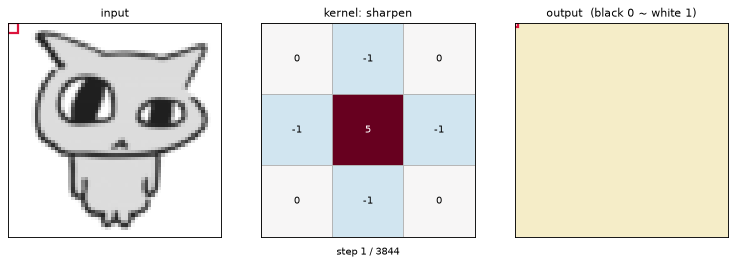

In [7]:
show_conv_overview(XP, OUT, STEPS, KERNEL, KERNEL_NAME)


### 1-2. [TODO] 커널을 직접 설계하기

커널을 어떻게 설계하는지가 곧 **어떤 특징을 잡을지**를 결정합니다.
위 셀에서 쓴 커널은 sharpen으로, 가운데를 키우고 주변을 빼서 경계를 또렷하게 만드는 커널이었습니다.

**여러분이 뽑아내고 싶은 특징을 하나 정하고, 그 특징에 반응하는 커널을 직접 만들어 보세요.**

1. 무엇을 뽑아내고 싶은지 정합니다. (예: 특정 방향의 경계, 밝기 변화, 흐림 …)
2. 그 의도에 맞게 **MY_KERNEL** 의 숫자를 채웁니다. 크기는 자유지만 **홀수 정사각형**(3×3, 5×5 …)으로 하세요.
   홀수 크기의 커널은 중심 픽셀이 명확해 현재 위치를 기준으로 연산하기 편리합니다.
3. 결과를 확인하고, **왜 그렇게 나왔는지** 아래 칸에 설명을 씁니다.


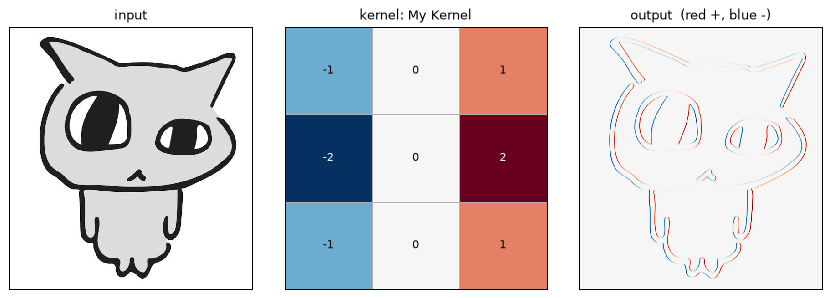

In [8]:
MY_KERNEL_NAME = "My Kernel"

MY_KERNEL = kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32) 

result = show_kernel_result(IMG_FULL, MY_KERNEL, MY_KERNEL_NAME)


**[TODO] 설명을 여기에 쓰세요.**

- 뽑아내려 한 특징: 수직 방향의 경계, 즉 좌우로 밝기가 급격하게 변하는 부분
- 커널을 그렇게 구성한 이유: Sobel X 형태의 커널을 사용하여 왼쪽 픽셀에는 음의 가중치, 오른쪽 픽셀에는 양의 가중치를 주었다.
따라서 좌우 밝기 차이가 큰 위치에서 큰 값이 나타나도록 구성하였다.
- 결과에서 관찰한 것: 이미지에서 수직 방향의 윤곽이나 좌우 밝기 변화가 큰 부분이 강조되었다.
반면 밝기가 비슷하게 유지되는 영역에서는 값이 작게 나타났다.

In [ ]:
class RNNClassifier(nn.Module):
    """단어를 하나씩 순서대로 읽는다. 마지막 hidden으로 분류."""

    def __init__(self, vocab_size, emb=100, hid=128, n_class=2):
        super().__init__()
        self.hid = hid
        self.emb = nn.Embedding(vocab_size, emb, padding_idx=0)
        self.W_ih = nn.Linear(emb, hid, bias=False)
        self.W_hh = nn.Linear(hid, hid, bias=True)
        self.fc = nn.Linear(hid, n_class)

    def forward(self, x, lens):
        B, T = x.shape
        e = self.emb(x)

        h = torch.zeros(B, self.hid, device=x.device)
        H = []

        for t in range(T):
            x_t = e[:, t, :]

            h = torch.tanh(
                self.W_ih(x_t) + self.W_hh(h)
            )

            H.append(h)

        H = torch.stack(H, dim=1)

        last = H[
            torch.arange(B, device=x.device),
            (lens - 1).clamp(min=0)
        ]

        return self.fc(last)


torch.manual_seed(SEED)

rnn = RNNClassifier(len(ITOS))
print(f"파라미터 {sum(p.numel() for p in rnn.parameters()):,}개")

rnn_time, rnn_hist = train_classifier(
    rnn,
    X_TRAIN,
    L_TRAIN,
    Y_TRAIN,
    DEVICE,
    epochs=3,
    seed=SEED
)

rnn_acc, rnn_bins = evaluate(
    rnn,
    X_TEST,
    L_TEST,
    Y_TEST,
    DEVICE,
    LEN_BINS
)

print(
    f"  정확도 {rnn_acc:.4f}   " +
    "  ".join(f"{lab} {a:.4f}" for lab, a in rnn_bins)
)

파라미터 2,029,570개


KeyboardInterrupt: 

### 1-3. 내 커널이 훑고 지나가는 모습

직접 만든 커널로도 이동 과정을 확인해 보세요.

KeyboardInterrupt: 

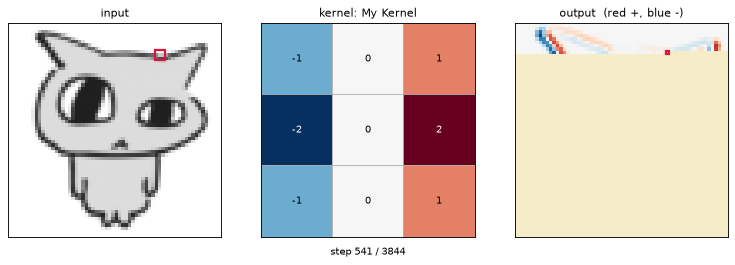

In [10]:
MY_XP, MY_OUT, MY_STEPS = conv2d_steps(IMG, MY_KERNEL, stride=1, padding=0)

show_conv_overview(MY_XP, MY_OUT, MY_STEPS, MY_KERNEL, MY_KERNEL_NAME)

---

## 2. U-Net 구현해보기

앞에서 convolution이 이미지의 국소적인 특징을 추출하는 방법을 살펴봤습니다.
이번에는 convolution block을 여러 층 쌓아 만든 **U-Net**을 직접 구현해 봅니다.

U-Net(Ronneberger et al., 2015)은 원래 의료 영상 segmentation을 위해 제안된 모델로,
구조가 알파벳 **U 모양**과 비슷해 U-Net이라는 이름이 붙었습니다.

U-Net은 크게 세 부분으로 볼 수 있습니다.

1. **Downsampling (Encoder)**  
   convolution으로 특징을 추출하면서 pooling을 통해 feature map의 공간 크기를 줄입니다.  
   해상도는 낮아지지만, 여러 층을 거치면서 단순한 경계나 질감에서 더 복잡한 형태와 구조에 관한 특징을 표현하게 됩니다.

2. **Bottleneck**  
   U-Net에서 feature map의 크기가 가장 작고 채널 수가 가장 많은 지점입니다.  
   입력 이미지에서 추출된 고수준의 특징이 압축되어 표현됩니다.

3. **Upsampling (Decoder)**  
   줄어든 feature map의 크기를 다시 키우면서 최종 출력의 해상도를 복원합니다.

그런데 downsampling 과정에서 공간 해상도를 줄이면,
원래 이미지의 세밀한 위치 정보 일부는 손실될 수 있습니다.

U-Net은 이를 보완하기 위해 **skip connection**을 사용합니다.
Encoder에서 얻은 높은 해상도의 feature map을 같은 해상도의 Decoder 단계로 직접 전달하여,
upsampling 과정에서 세부적인 공간 정보를 더 잘 복원할 수 있도록 합니다.

즉, U-Net의 핵심은 단순히 이미지를 줄였다가 다시 키우는 것이 아니라,

**Downsampling에서 얻은 고수준 특징과 Skip connection으로 전달된 고해상도 정보를 함께 사용해 출력을 복원하는 것**에 있습니다.

---

### 논문 원본 구조

**U-Net 구조도** (Ronneberger et al., 2015)

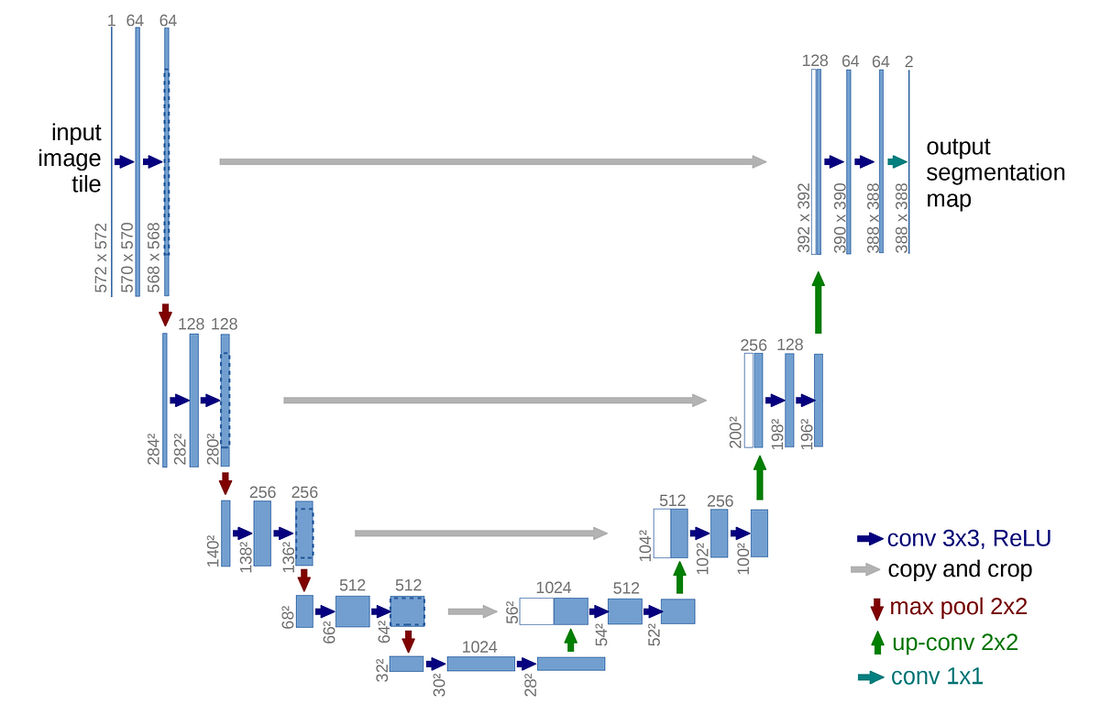


원 논문에서는 **padding=0**인 convolution을 사용하기 때문에
convolution을 거칠 때마다 feature map의 크기가 조금씩 줄어듭니다.
따라서 skip connection으로 두 feature map을 연결하기 전에
Encoder의 feature map을 crop하여 크기를 맞추는 과정이 필요합니다.

### 이번 과제에서 구현할 U-Net

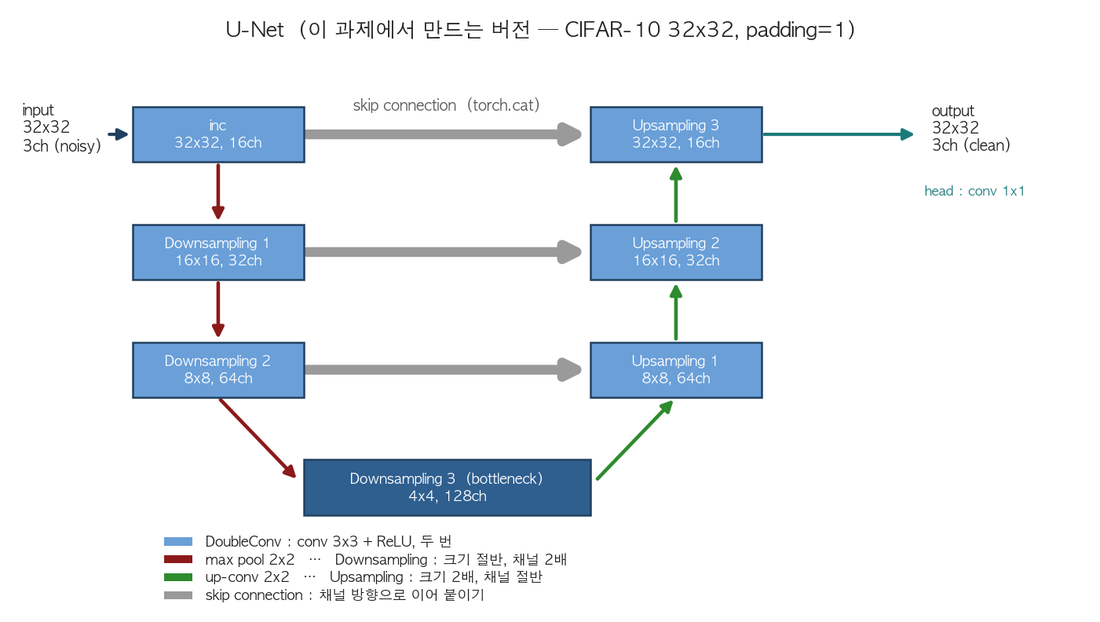


이번 과제에서는 U-Net의 핵심 구조에 집중할 수 있도록 조금 단순화한 버전 구현을 목표로 합니다.

- convolution에 **padding=1**을 사용해 공간 크기를 유지합니다.
- 따라서 skip connection에서 별도의 crop 없이 **torch.cat**으로 feature map을 연결할 수 있습니다.
- 입력과 출력은 모두 **32×32 RGB 이미지**입니다.
- 채널 수는 **16 → 32 → 64 → 128**로 사용합니다.
- Downsampling은 총 3번 수행합니다.

이후 직접 U-Net을 구현하고,

- 각 단계에서 feature map의 **크기와 채널 수가 어떻게 변하는지**
- downsampling으로 잃어버린 정보를 upsampling만으로 복원할 수 있는지
- **skip connection이 실제 복원 성능에 어떤 영향을 주는지**

차례대로 확인해 봅시다.

### 2-1. 데이터 준비 — CIFAR-10

U-Net을 학습시키기 위해서 이미지가 여러 장 필요합니다.

그래서 CIFAR-10(32×32 컬러 이미지)을 씁니다. **배포된 data/dsl_part2_data.npz 에 이미 들어 있으니 내려받을 필요가 없습니다.**

학습에는 4,000장을 쓰고, **평가는 학습에 한 번도 쓰지 않은 test 이미지**로 합니다.


CIFAR-10 : 번들에서 읽음 (다운로드 없음)
학습 (4000, 3, 32, 32)   평가 (16, 3, 32, 32)
값 범위 [0.00, 1.00],  노이즈 세기 0.1


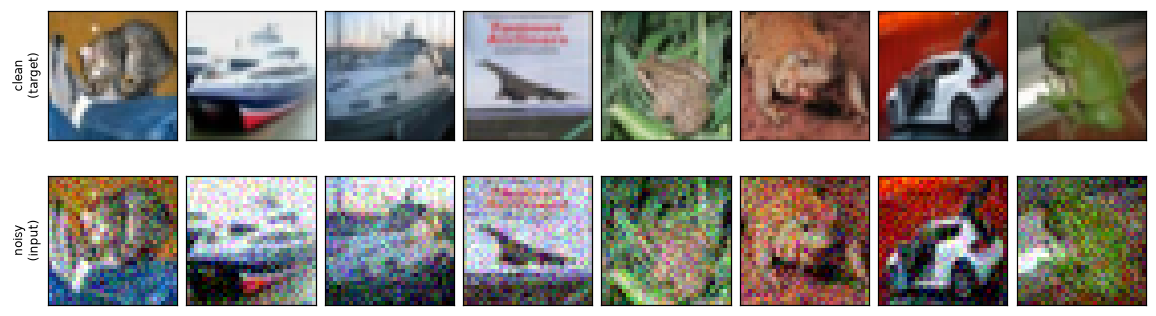

노이즈 낀 입력 그대로의 PSNR : 20.29 dB
  (모델은 이 숫자보다 높아야 '노이즈를 줄였다'고 할 수 있습니다)


In [11]:
N_TRAIN = 4000        
N_TEST  = 16         
NOISE   = 0.1         # 입력에 섞을 노이즈 세기. 모델의 효과를 시각적으로 확인하기 위해 입력에 노이즈를 섞어 학습합니다.

_cifar  = load_cifar(root="./data", n_train=N_TRAIN, n_test=N_TEST)
TRAIN_X = _cifar["train"]          # (N_TRAIN, 3, 32, 32),  값 범위 0~1
TEST_X  = _cifar["test"]

# 평가용 노이즈는 고정
_g = torch.Generator().manual_seed(0)
TEST_NOISY = (TEST_X + NOISE * torch.randn(TEST_X.shape, generator=_g)).clamp(0, 1)

print(f"학습 {tuple(TRAIN_X.shape)}   평가 {tuple(TEST_X.shape)}")
print(f"값 범위 [{TRAIN_X.min():.2f}, {TRAIN_X.max():.2f}],  노이즈 세기 {NOISE}")

show_noisy_pairs(TEST_X, TEST_NOISY)


### 2-2. [TODO] U-Net 구현하기

**DoubleConv**와 **UNet** 두 개의 class를 정의합니다.

**DoubleConv** — 구조도의 파란 상자 하나에 해당합니다.  
**3×3 Conv → ReLU**를 **두 번** 반복합니다. Downsampling과 Upsampling 모두에서 이 블록을 사용합니다. **padding=1**이므로 feature map의 공간 크기는 유지되고 채널 수만 변합니다.

**UNet** — __init__을 **Downsampling 부분과 Upsampling 부분으로 나누어** 구현합니다.

#### Downsampling
구조도의 빨간 화살표와 파란 상자에 해당합니다.

- MaxPool2d(2)로 feature map의 크기를 **절반**으로 줄입니다.
- 이후 **DoubleConv**를 거치며 채널 수를 **두 배**로 늘립니다.
- 공간 해상도가 줄어들면서 세부적인 위치 정보는 일부 손실될 수 있지만, 여러 convolution layer를 거치면서 더 넓은 영역의 특징을 표현하게 됩니다.
- Max pooling에는 학습되는 파라미터가 없으므로 **MaxPool2d(2)** 모듈 하나를 만들어 여러 단계에서 재사용해도 됩니다.

#### Upsampling
구조도의 초록 화살표, 회색 화살표, 파란 상자에 해당합니다.

- ConvTranspose2d(kernel_size=2, stride=2)로 feature map의 크기를 **두 배**로 늘립니다.
- 같은 해상도를 가지는 Encoder 쪽 feature map을 skip connection을 통해 가져와 **채널 방향으로 이어 붙입니다** (torch.cat).
- 이어 붙인 feature map을 **DoubleConv**에 통과시켜 다음 단계의 특징을 만듭니다.
- Skip connection을 사용하면 두 feature map의 채널이 합쳐지므로, **DoubleConv**의 **입력 채널 수를 이에 맞게 설정해야 합니다.**

| 단계 | 크기 | 채널 (base=16) |
|---|---|---|
| inc | 32×32 | 16 |
| Downsampling 1 | 16×16 | 32 |
| Downsampling 2 | 8×8 | 64 |
| Downsampling 3 **(bottleneck)** | **4×4** | **128** |
| Upsampling 1 | 8×8 | 64 |
| Upsampling 2 | 16×16 | 32 |
| Upsampling 3 | 32×32 | 16 |
| output | 32×32 | 3 |

입력과 출력은 모두 **RGB 3채널 이미지**입니다.  
노이즈가 섞인 이미지를 입력으로 받아 깨끗한 원본 이미지를 복원하도록 모델을 학습합니다.

**forward**에서는 Downsampling 과정에서 얻은 feature map을 변수에 저장해 두었다가, Upsampling 과정에서 **같은 해상도를 가지는 feature map끼리 연결하는 것**이 핵심입니다.

- Upsampling 1 ↔ Downsampling 2
- Upsampling 2 ↔ Downsampling 1
- Upsampling 3 ↔ inc

**use_skip=False**로 설정하면 skip connection을 사용하지 않는 모델이 됩니다.  
이 경우 Encoder의 feature map을 이어 붙이지 않으므로 Upsampling 쪽 **DoubleConv**의 **입력 채널 수가 절반**이 됩니다.  
두 경우를 하나의 class에서 처리하려면 **s = 2 if use_skip else 1**과 같은 값을 두고 입력 채널 수에 곱해 주면 편리합니다.  
이 설정을 이용해 2-4에서 **skip connection의 효과를 직접 비교합니다.**

2-3 셀에서는 **forward(x, return_feats=True)**를 이용해 각 단계의 중간 feature map을 확인합니다.  
따라서 스켈레톤에 지정된 **반환 형식과 dictionary key 이름을 그대로 유지해 주세요.** 이름을 변경하면 2-3 셀에서 오류가 발생할 수 있습니다.

In [12]:
class DoubleConv(nn.Module):
    """conv 3x3 -> ReLU 를 두 번. U-Net의 기본 블록."""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """우리가 구현할 U-net 모델. use_skip=False 로 두면 skip connection연산이 없습니다."""

    def __init__(self, in_ch=3, out_ch=3, base=16, use_skip=True):
        super().__init__()
        self.use_skip = use_skip
        b = base
        s = 2 if use_skip else 1

        self.inc = DoubleConv(in_ch, b)

        self.downsampling = nn.MaxPool2d(kernel_size=2)

        self.down_conv1 = DoubleConv(b, b * 2)
        self.down_conv2 = DoubleConv(b * 2, b * 4)
        self.down_conv3 = DoubleConv(b * 4, b * 8)

        self.upsampling1 = nn.ConvTranspose2d(
            b * 8, b * 4, kernel_size=2, stride=2
        )
        self.upsampling2 = nn.ConvTranspose2d(
            b * 4, b * 2, kernel_size=2, stride=2
        )
        self.upsampling3 = nn.ConvTranspose2d(
            b * 2, b, kernel_size=2, stride=2
        )

        self.up_conv1 = DoubleConv(b * 4 * s, b * 4)
        self.up_conv2 = DoubleConv(b * 2 * s, b * 2)
        self.up_conv3 = DoubleConv(b * s, b)

        self.head = nn.Conv2d(b, out_ch, kernel_size=1)

    def join(self, up, skip):
        """skip connection. 올라온 것과 내려갈 때 나온 것을 채널 방향으로 붙인다."""
        if not self.use_skip:
            return up
        return torch.cat([up, skip], dim=1)

    def forward(self, x, return_feats=False):
        x1 = self.inc(x)
        x2 = self.down_conv1(self.downsampling(x1))
        x3 = self.down_conv2(self.downsampling(x2))
        x4 = self.down_conv3(self.downsampling(x3))

        u1 = self.up_conv1(self.join(self.upsampling1(x4), x3))
        u2 = self.up_conv2(self.join(self.upsampling2(u1), x2))
        u3 = self.up_conv3(self.join(self.upsampling3(u2), x1))

        y = self.head(u3)

        if return_feats:
            feats = {
                "inc": x1,
                "Down 1": x2,
                "Down 2": x3,
                "Down 3": x4,
                "Up 1": u1,
                "Up 2": u2,
                "Up 3": u3
            }
            return y, feats

        return y

### 2-3. Feature map의 변화 따라가 보기

이미지를 U-Net에 한 번 통과시키면서 **각 단계에서 feature map의 공간 크기와 채널 수가 어떻게 변하는지** 확인합니다.

Downsampling 과정에서는 공간 크기가  
**32×32 → 16×16 → 8×8 → 4×4**로 줄어들고,

Upsampling 과정에서는 다시  
**4×4 → 8×8 → 16×16 → 32×32**로 커집니다.

하지만 feature map의 크기가 다시 32×32가 되었다고 해서,
Downsampling 이전의 정보가 그대로 복원된 것은 아닙니다.

Max pooling은 작은 영역에서 하나의 대표값만 남기기 때문에
공간 해상도를 줄이는 과정에서 **세부적인 위치 정보가 손실될 수 있습니다.**
이후 Upsampling으로 feature map의 크기를 다시 키우더라도,
이미 사라진 정보를 단순히 크기를 늘리는 것만으로 완전히 복원하기는 어렵습니다.

U-Net은 이러한 문제를 보완하기 위해 **skip connection**을 사용합니다.
Downsampling 이전의 높은 해상도를 가진 feature map을
같은 해상도의 Upsampling 단계로 직접 전달하여,
Decoder가 복원 과정에서 **Encoder의 세부적인 공간 정보를 다시 활용할 수 있도록 합니다.**

이번 셀에서는 각 단계의 feature map 크기와 채널 수를 확인하고,
다음 실험에서는 skip connection의 유무가 실제 복원 성능에 어떤 차이를 만드는지 비교해 봅니다.


In [13]:
X = TEST_NOISY.to(DEVICE)

torch.manual_seed(SEED)     
model = UNet(in_ch=3, out_ch=3, base=16, use_skip=True).to(DEVICE)

model.eval()             
with torch.no_grad():  
    Y, FEATS = model(X, return_feats=True)

print(f"입력  {tuple(X.shape)}   ->   출력 {tuple(Y.shape)}")
print(f"파라미터 수 : {sum(p.numel() for p in model.parameters()):,}")
print()
for name, t in FEATS.items():
    mark = "Downsampling" if name.startswith(("inc", "Down")) else "Upsampling  "
    star = "   <- bottleneck" if name == "Down 3" else ""
    print(f"  {mark}  {name:<7} 크기 {t.shape[-2]:>2}x{t.shape[-1]:<2} "
          f" 채널 {t.shape[1]:>3}{star}")


입력  (16, 3, 32, 32)   ->   출력 (16, 3, 32, 32)
파라미터 수 : 482,067

  Downsampling  inc     크기 32x32  채널  16
  Downsampling  Down 1  크기 16x16  채널  32
  Downsampling  Down 2  크기  8x8   채널  64
  Downsampling  Down 3  크기  4x4   채널 128   <- bottleneck
  Upsampling    Up 1    크기  8x8   채널  64
  Upsampling    Up 2    크기 16x16  채널  32
  Upsampling    Up 3    크기 32x32  채널  16


### 2-4. [TODO] Skip connection이 있을 때와 없을 때

이번에는 U-Net을 **노이즈 제거(denoising)** 문제에 학습시켜,
skip connection이 복원 성능에 어떤 영향을 주는지 직접 비교합니다.

노이즈가 섞인 이미지를 입력으로 넣고,
깨끗한 원본 이미지를 target으로 사용합니다.
따라서 별도의 클래스 라벨은 필요하지 않습니다.

학습할 때는 같은 이미지에 대해서도 **매 step마다 새로운 노이즈를 생성해 추가합니다.**
따라서 모델이 특정한 노이즈 패턴에 의존하기보다는,
여러 형태의 노이즈가 포함된 입력에서 원본 이미지를 복원하는 방법을 학습하게 됩니다.

같은 조건에서

- **skip connection을 사용하는 모델**
- **skip connection을 사용하지 않는 모델**

을 각각 학습한 뒤,
**학습에 사용하지 않은 test 이미지**에서 성능을 비교합니다.

평가 지표로는 PSNR(Peak Signal-to-Noise Ratio)을 사용합니다.
PSNR은 복원된 이미지와 원본 이미지의 차이를 나타내는 지표로,
일반적으로 값이 높을수록 원본에 가까운 복원 결과를 의미합니다.

동일한 pixel range를 사용할 때 PSNR은 MSE와 반비례하는 관계를 가지며,
PSNR이 약 **3 dB 증가하면 MSE는 절반 수준으로 감소**합니다.

노이즈가 섞인 입력 이미지 자체의 PSNR도 함께 출력됩니다.
두 모델의 결과가 입력 상태보다 얼마나 개선되었는지,
그리고 **skip connection의 유무에 따라 어떤 차이가 나타나는지** 확인해 보세요.

> GPU에서는 두 모델을 학습하는 데 약 1분 정도 걸릴 수 있으며,
> CPU에서는 더 오래 걸릴 수 있습니다.
> 실행 시간이 너무 길다면 `EPOCHS`를 20 정도로 줄여도 됩니다.
> 변경했다면 답안에 사용한 `EPOCHS`를 함께 적어 주세요.

> 실행 환경이나 random seed에 따라 구체적인 PSNR 값은 달라질 수 있습니다.
> 절대적인 수치보다는 **두 모델의 상대적인 성능 차이와 그 이유**에 집중해서 결과를 해석해 주세요.

use_skip=True   test PSNR 26.56 dB
use_skip=False  test PSNR 15.54 dB


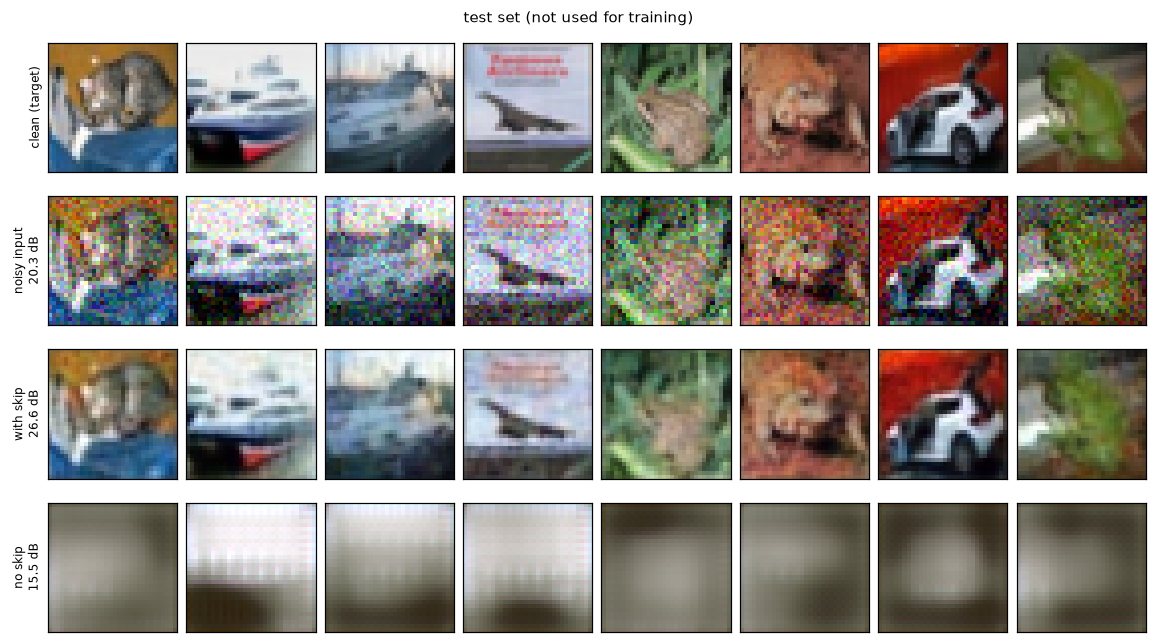

PSNR   noisy 입력 20.29 dB  |  with skip 26.56 dB  |  no skip 15.54 dB
       skip이 +11.02 dB 우세   (오차 기준 12.7배 차이)
       no skip은 노이즈 낀 입력보다도 4.75 dB 나쁩니다.


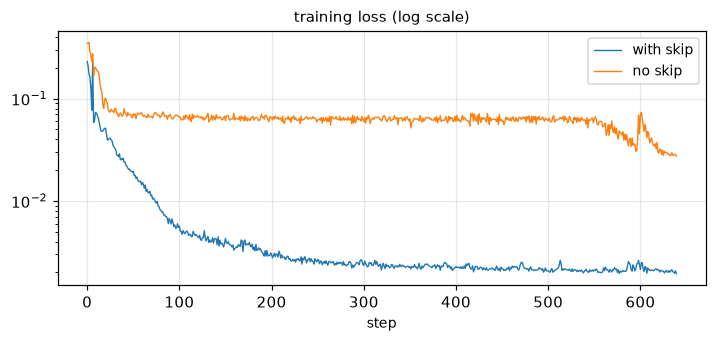

In [15]:
EPOCHS = 20       


def train_unet(use_skip, epochs=EPOCHS, batch_size=128, lr=2e-3, seed=SEED):
    """노이즈를 제거하도록 U-Net을 학습시킨다."""
    torch.manual_seed(seed) 
    net = UNet(in_ch=3, out_ch=3, base=16, use_skip=use_skip).to(DEVICE)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    history = []
    for ep in range(epochs):
        perm = torch.randperm(len(TRAIN_X))
        for i in range(0, len(TRAIN_X), batch_size):
            clean = TRAIN_X[perm[i:i + batch_size]].to(DEVICE)

            noisy = (clean + NOISE * torch.randn_like(clean)).clamp(0, 1)

            opt.zero_grad()
            loss = loss_fn(net(noisy), clean)
            loss.backward()
            opt.step()
            history.append(loss.item())

    net.eval()
    with torch.no_grad():
        pred = net(TEST_NOISY.to(DEVICE)).cpu().clamp(0, 1)

    print(f"use_skip={str(use_skip):<5}  test PSNR {psnr(pred, TEST_X):.2f} dB")
    return net, pred, history


net_skip,   pred_skip,   hist_skip   = train_unet(use_skip=True)
net_noskip, pred_noskip, hist_noskip = train_unet(use_skip=False)

show_denoise_compare(TEST_X, TEST_NOISY, pred_skip, pred_noskip,
                     hist_skip, hist_noskip)

**[TODO] 결과를 관찰하고 아래 질문에 답하세요.**

1. skip connection을 사용하지 않은 모델의 출력은
   skip connection을 사용한 모델과 비교했을 때 어떤 차이가 나타났나요?
   특히 **전체적인 형태와 세부적인 공간 정보**를 나누어 관찰해 보세요.

2. skip connection을 사용하지 않은 모델의 PSNR을
   **노이즈가 섞인 입력 이미지의 PSNR**과 비교해 보세요.
   두 값의 관계는 모델의 복원 성능에 대해 무엇을 의미하나요?

3. U-Net의 bottleneck에서는 feature map의 공간 크기가 **4×4**까지 줄어듭니다.
   그럼에도 skip connection을 사용한 모델이 더 세밀한 결과를 만들 수 있다면,
   **skip connection을 통해 어떤 정보가 전달되기 때문인지** 설명해 보세요.

4. Segmentation처럼 **픽셀 단위의 위치 정보가 중요한 문제**에서
   skip connection이 어떤 역할을 할 수 있는지 설명해 보세요.

EPOCHS = 20

1. skip connection을 사용하지 않은 모델은 전체적인 물체의 형태는 어느 정도 복원했지만,
skip connection을 사용한 모델에 비해 경계나 작은 구조와 같은 세부적인 공간 정보가 더 흐릿하게 나타났다.
반면 skip connection을 사용한 모델은 전체적인 형태뿐 아니라 윤곽과 세부 위치 정보도 더 잘 복원하였다.

2. 노이즈가 섞인 입력 이미지의 PSNR은 20.29 dB이고,
skip connection을 사용하지 않은 모델의 PSNR은 15.54 dB이다.
No-skip 모델의 PSNR이 입력 이미지보다 높다면 모델이 노이즈를 제거하여 원본에 더 가까운 이미지를 만들었다는 의미이다.
반대로 입력보다 낮다면 충분한 복원 성능을 얻지 못한 것으로 해석할 수 있다.
이번 실험에서 skip connection을 사용한 모델의 PSNR은 26.56 dB로,
세부적인 공간 정보를 전달하는 skip connection이 복원 성능 향상에 도움을 주었음을 확인할 수 있다.

3. bottleneck에서는 feature map의 공간 크기가 4×4까지 줄어들기 때문에
downsampling 과정에서 세밀한 위치 정보가 많이 손실될 수 있다.
skip connection은 encoder의 높은 해상도 feature map을 decoder에 직접 전달하므로,
경계, 세부 구조, 정확한 위치와 같은 공간 정보를 bottleneck을 거치지 않고 활용할 수 있다.

4. Segmentation은 각 픽셀이 어떤 클래스에 속하는지를 판단해야 하므로 정확한 위치 정보가 중요하다.
skip connection은 encoder의 고해상도 feature를 decoder에 전달하여
downsampling 과정에서 손실된 위치 정보를 보완한다.
따라서 물체의 경계나 작은 영역을 더 정확하게 구분하는 데 도움을 줄 수 있다.

---

## 3. RNN 방식 vs Attention 방식

이미지와 달리 문장은 **순서가 있는 sequence 데이터**이며, 문장마다 길이도 다릅니다.

Transformer가 등장하기 전에는 이러한 sequence 데이터를 처리하기 위해 **RNN 계열의 모델**이 널리 사용되었습니다.
RNN은 입력 토큰을 순서대로 읽으면서 이전 hidden state의 정보를 다음 hidden state로 전달합니다.

$$
h_t = \tanh(W_{ih}x_t + W_{hh}h_{t-1} + b)
$$

이번 과제에서 구현할 RNN classifier는 각 토큰을 순서대로 처리한 뒤,
**마지막 유효 토큰의 hidden state**를 문장을 나타내는 벡터로 사용하여 분류합니다.

RNN의 이러한 구조에는 두 가지 특징이 있습니다.

1. **시간 축의 병렬화가 어렵습니다.**  
   현재 hidden state $h_t$를 계산하려면 이전 hidden state $h_{t-1}$가 먼저 계산되어야 합니다.
   따라서 batch에 포함된 여러 문장은 동시에 처리할 수 있지만,
   하나의 sequence 내부에서는 토큰을 순서대로 처리해야 합니다.
   Sequence가 길어질수록 이러한 순차적인 연산도 길어집니다.

2. **긴 거리의 정보를 전달하기 어려울 수 있습니다.**  
   앞부분의 정보가 뒤쪽까지 전달되려면 여러 recurrent step을 연속해서 거쳐야 합니다.
   특히 기본 RNN에서는 이 과정에서 gradient가 작아지거나 커지는 문제가 발생할 수 있어,
   멀리 떨어진 토큰 사이의 관계를 학습하는 데 어려움이 생길 수 있습니다.

반면 **Self-Attention**에서는 각 토큰으로부터 Query, Key, Value를 만들고,
모든 토큰 쌍의 관계를 한 번에 계산합니다.

$$
\text{Attention}(Q,K,V)
=
\text{softmax}\!\left(
\frac{QK^{\top}}{\sqrt{d}}
\right)V
$$

이 방식에서는 한 위치의 표현을 계산할 때 다른 위치의 정보를 직접 참조할 수 있으며,
sequence의 각 위치에 대한 계산을 행렬 연산을 통해 병렬적으로 수행할 수 있습니다.

이번 섹션에서는 RNN과 Self-Attention 기반 classifier를 직접 구현하여
**같은 데이터에서 학습 시간과 분류 성능을 비교합니다.**

마지막에는 정답을 결정하는 단서를 맨 앞에 두고 sequence 길이만 변화시키는 인공 실험을 통해, 기본 RNN에서 장기 의존성 문제가 어떻게 나타나는지와 두 방식의 실행 시간 변화를 확인합니다.

Self-Attention에도 비용이 있습니다.  
길이가 $T$인 sequence에서는 모든 토큰 쌍의 attention score를 계산하므로
$T\times T$ 크기의 score matrix가 만들어집니다.
따라서 sequence 길이가 증가하면 계산량과 메모리 사용량이 크게 증가합니다.
반면 기본 RNN은 sequence 길이에 따라 필요한 recurrent step의 수가 선형적으로 증가합니다.
이후 실험에서 sequence 길이에 따른 두 방식의 실행 시간도 함께 비교해 봅니다.

### 3-1. 데이터 준비 — IMDB 영화 리뷰

IMDB 영화 리뷰를 읽고 **긍정/부정 감성을 분류**하는 문제입니다.
원본 데이터는 학습 25,000개와 평가 25,000개로 구성되어 있습니다.

이번 과제에서는 실행 시간을 고려해 학습 데이터 중 **20,000개**를 사용합니다.
또한 sequence 길이를 최대 **400토큰**으로 제한하기 위해,
원문 길이가 400토큰을 초과하는 리뷰는 제외합니다.

토크나이징이 완료된 데이터는
**data/dsl_part2_data.npz**에 미리 저장되어 있으므로 별도로 다운로드할 필요가 없습니다.

리뷰마다 실제 길이가 다르기 때문에 짧은 문장은 뒤쪽이 padding으로 채워집니다.
각 문장의 **실제 길이**도 함께 저장하여 RNN의 마지막 유효 토큰을 선택하거나,
Attention에서 padding을 계산에서 제외할 때 사용합니다.

실행하면 리뷰 길이에 따라 **짧음 / 중간 / 긺** 세 구간으로 나눈 통계도 함께 출력됩니다.


In [18]:
globals().update(imdb_setup(root="./data", max_len=400,
                            vocab_size=20000, n_train=20000))

print()
print("리뷰 예시 (앞 40 토큰):")
print("  ", " ".join(TEST_TOKENS[0][:40]), "...")
print("  정답 :", "긍정" if Y_TEST[0] == 1 else "부정")

IMDB : 번들에서 읽음 (다운로드 없음)
학습 (20000, 400)   평가 (21892, 400)
vocab 20,000개,  max_len 400
리뷰 길이 중앙값 158 토큰  (모두 400토큰 이하, 잘린 리뷰 없음)
길이 구간 (경계 132 / 196)
    짧음    6~132  토큰     7387개
    중간  133~196  토큰     7219개
    긺    197~400  토큰     7286개

리뷰 예시 (앞 40 토큰):
   i went and saw this movie last night after being coaxed to by a few friends of mine i'll admit that i was reluctant to see it because from what i knew of ashton kutcher he was only able to ...
  정답 : 긍정


### 3-2. [TODO] RNN 방식 만들기

**RNNClassifier**를 완성합니다.

이번 구현에서 핵심은 **이전 hidden state와 현재 토큰의 embedding을 이용해
새로운 hidden state를 순서대로 계산하는 것**입니다.

한 시점 $t$에서 hidden state는 다음과 같이 갱신됩니다.

$$
h_t = \tanh(W_{ih}e_t + W_{hh}h_{t-1})
$$

코드에서는 이 연산을 **for**문으로 sequence의 처음부터 끝까지 반복합니다.

h = torch.tanh(W_ih(e_t) + W_hh(h))

각 시점의 hidden state는 H에 저장됩니다.
문장마다 길이가 다르므로 분류에는 H의 마지막 위치가 아니라 padding 직전의 마지막 유효 토큰의 hidden state를 사용합니다. 이 부분은 제공된 코드에서 lens를 이용해 처리합니다.

In [19]:
class RNNClassifier(nn.Module):
    """단어를 하나씩 순서대로 읽는다. 마지막 hidden으로 분류."""

    def __init__(self, vocab_size, emb=100, hid=128, n_class=2):
        super().__init__()
        self.hid = hid
        self.emb = nn.Embedding(vocab_size, emb, padding_idx=0)
        self.W_ih = nn.Linear(emb, hid, bias=False)
        self.W_hh = nn.Linear(hid, hid, bias=True)
        self.fc = nn.Linear(hid, n_class)

    def forward(self, x, lens):
        B, T = x.shape
        e = self.emb(x)

        h = torch.zeros(B, self.hid, device=x.device)
        H = []

        for t in range(T):
            x_t = e[:, t, :]

            h = torch.tanh(
                self.W_ih(x_t) + self.W_hh(h)
            )

            H.append(h)

        H = torch.stack(H, dim=1)

        last = H[
            torch.arange(B, device=x.device),
            (lens - 1).clamp(min=0)
        ]

        return self.fc(last)


torch.manual_seed(SEED)

rnn = RNNClassifier(len(ITOS))
print(f"파라미터 {sum(p.numel() for p in rnn.parameters()):,}개")

rnn_time, rnn_hist = train_classifier(
    rnn,
    X_TRAIN,
    L_TRAIN,
    Y_TRAIN,
    DEVICE,
    epochs=3,
    seed=SEED
)

rnn_acc, rnn_bins = evaluate(
    rnn,
    X_TEST,
    L_TEST,
    Y_TEST,
    DEVICE,
    LEN_BINS
)

print(
    f"  정확도 {rnn_acc:.4f}   " +
    "  ".join(f"{lab} {a:.4f}" for lab, a in rnn_bins)
)

파라미터 2,029,570개


KeyboardInterrupt: 

### 3-3. [TODO] Attention 방식 만들기

이번에는 RNN처럼 시간 순서대로 hidden state를 갱신하지 않고,
**Self-Attention을 이용해 sequence의 모든 위치를 함께 처리**합니다.

각 토큰의 embedding을 세 가지 표현으로 변환합니다.

| | 역할 |
|---|---|
| **Q** (Query) | 현재 위치에서 어떤 정보를 찾을지 나타내는 표현 |
| **K** (Key) | 각 위치가 어떤 정보를 가지고 있는지 비교하기 위한 표현 |
| **V** (Value) | Attention 결과에 실제로 전달되는 정보 |

Self-Attention의 핵심 연산은 다음과 같습니다.

1. **Attention score 계산**  
   각 Query와 모든 Key의 유사도를 계산합니다.

   **Q @ K.transpose(1, 2) → (B, T, T)**

2. **Scaling**  
   score를 $\sqrt{d_k}$로 나누어 값의 크기를 조절합니다.

3. **Softmax와 Weighted Sum**  
   score에 softmax를 적용해 attention weight를 만든 뒤,
   각 Value를 attention weight에 따라 가중합합니다.

   **softmax(scores) @ V**

실제 batch에는 길이가 다른 문장을 맞추기 위한 padding이 포함되어 있습니다.
Padding token이 Attention의 참조 대상이 되지 않도록 하는 masking 코드는 미리 제공되어 있습니다.
해당 부분은 수정하지 않고 그대로 사용하세요.

---

### Positional Embedding

Self-Attention 연산 자체에는 토큰의 **순서 정보가 포함되어 있지 않습니다.**

따라서 positional embedding이 없다면 입력 토큰의 순서를 바꾸었을 때
Self-Attention의 출력도 같은 방식으로 위치만 바뀌게 됩니다.

이번 모델에서는 마지막에 각 위치의 표현을 평균내어 문장 하나의 벡터로 만들기 때문에,
positional embedding이 없다면 **같은 토큰으로 구성되고 순서만 다른 문장을 구분하기 어렵습니다.**

따라서 token embedding에 **positional embedding을 더해 각 토큰의 위치 정보를 함께 전달합니다.**

RNN은 현재 hidden state가 이전 hidden state에 의존하므로 sequence를 순서대로 처리해야 합니다.  
반면 Self-Attention은 모든 토큰 쌍의 관계를 행렬 연산으로 계산할 수 있어,
sequence의 여러 위치를 병렬적으로 처리할 수 있습니다.

여기서 구현하는 것은 **single-head self-attention**입니다.  
Transformer에서는 이를 여러 head로 확장한 Multi-Head Attention을 사용하고,
residual connection, layer normalization, feed-forward network 등을 결합해 여러 블록으로 쌓습니다.
이번 구현에서는 그중 **Self-Attention의 핵심 연산**에 집중합니다.

In [ ]:
class AttentionClassifier(nn.Module):

    def __init__(self, vocab_size, emb=100, hid=128, max_len=400, n_class=2):
        super().__init__()
        self.hid = hid
        self.emb = nn.Embedding(vocab_size, emb, padding_idx=0)
        self.pos = nn.Embedding(max_len, emb)
        self.q = nn.Linear(emb, hid)
        self.k = nn.Linear(emb, hid)
        self.v = nn.Linear(emb, hid)
        self.fc = nn.Linear(hid, n_class)

    def forward(self, x, lens, return_weights=False):
        B, T = x.shape
        pos = torch.arange(T, device=x.device)[None, :].expand(B, T)
        e = self.emb(x) + self.pos(pos)

        Q, K, V = self.q(e), self.k(e), self.v(e)

        # TODO 모든 단어 쌍의 점수를 한 번에
        scores = torch.matmul(Q, K.transpose(-2, -1))

        # TODO 스케일
        scores = scores / math.sqrt(Q.size(-1))

        # 3) 패딩 자리는 -inf -> softmax 후 0
        mask = torch.arange(T, device=x.device)[None, :] < lens[:, None]
        scores = scores.masked_fill(~mask[:, None, :], float("-inf"))

        # TODO 가중합
        A = torch.softmax(scores, dim=-1)
        H = torch.matmul(A, V)    

        m = mask.unsqueeze(-1).float()
        ctx = (H * m).sum(1) / m.sum(1).clamp(min=1)

        logits = self.fc(ctx)
        return (logits, A) if return_weights else logits


torch.manual_seed(SEED) 
attn = AttentionClassifier(len(ITOS), max_len=MAX_LEN)
print(f"파라미터 {sum(p.numel() for p in attn.parameters()):,}개")

attn_time, attn_hist = train_classifier(attn, X_TRAIN, L_TRAIN, Y_TRAIN,
                                        DEVICE, epochs=3, seed=SEED)
attn_acc, attn_bins = evaluate(attn, X_TEST, L_TEST, Y_TEST, DEVICE, LEN_BINS)

print(f"  정확도 {attn_acc:.4f}   " +
      "  ".join(f"{lab} {a:.4f}" for lab, a in attn_bins))

파라미터 2,079,042개
  학습 32.8초   마지막 loss 0.1832
  정확도 0.8531   짧음 0.8592  중간 0.8539  긺 0.8461


### 3-4. RNN과 Attention 비교

이제 두 모델의 결과를 비교합니다.

가능한 한 비슷한 조건에서 비교하기 위해 **학습 데이터, vocabulary, embedding·hidden 크기, epoch, seed**를 동일하게 설정했습니다.
학습 시간과 전체 정확도뿐 아니라 **문장 길이 구간별 정확도**도 함께 확인합니다.

다만 두 모델의 조건이 완전히 동일한 것은 아닙니다.

- RNN은 **마지막 유효 토큰의 hidden state**를 문장 표현으로 사용합니다.
- Attention 모델은 모든 위치의 출력을 계산한 뒤 **padding을 제외하고 평균**하여 문장 표현을 만듭니다.
- Attention 모델에는 토큰의 순서를 나타내기 위한 **positional embedding**이 추가되어 있습니다.
- 따라서 두 모델의 파라미터 수와 구조에도 약간의 차이가 있습니다.

따라서 정확도 차이를 단순히 Attention 연산 하나의 효과라고 해석하기보다는, 두 모델이 sequence를 처리하고 문장 표현을 만드는 방식의 차이를 함께 고려해야 합니다.

이번 비교는 두 모델의 성능을 엄밀하게 통제한 benchmark라기보다, RNN과 Self-Attention의 구조적 차이가 학습 시간과 분류 성능에 어떻게 나타나는지 관찰하기 위한 실험입니다.

다음에서는 실제 결과를 바탕으로 학습 시간과 정확도 차이가 어디에서 비롯되었는지 생각해 봅니다.


In [ ]:
show_arch_compare({
    "RNN":       (rnn_time,  rnn_acc,  rnn_bins),
    "Attention": (attn_time, attn_acc, attn_bins),
})

NameError: name 'show_arch_compare' is not defined

### 3-5. [TODO] 결과 해석

**위의 실험 결과와 두 모델의 구조를 비교하여 아래 질문에 답하세요.**

1. RNN과 Attention 모델의 **학습 시간에는 어떤 차이**가 나타났나요?  
   두 모델의 **forward** 과정을 비교하여 이러한 차이가 발생한 이유를 설명해 보세요.

2. 두 모델의 **전체 정확도와 리뷰 길이 구간별 정확도**를 비교해 보세요.  
   리뷰 길이가 증가할 때 각 모델의 성능이 어떻게 변하는지 관찰하고 설명해 보세요.

3. (이번 실험에서 Attention 모델의 정확도가 더 높게 나타났다면)
   이 차이를 **Self-Attention 연산만의 효과라고 단정할 수 없는 이유**는 무엇인가요?  
   두 모델이 문장 전체를 하나의 벡터로 만드는 방식과 positional embedding의 유무도 함께 고려하세요.

4. RNN과 비교했을 때 Self-Attention이 가지는 **구조적인 이점**은 무엇인가요?  
   **시간 축의 병렬 처리**와 **멀리 떨어진 토큰 사이의 정보 전달 경로**를 중심으로 설명해 보세요.

1. RNN은 각 시점의 hidden state가 이전 hidden state에 의존하므로 sequence를 처음부터 끝까지 순차적으로 계산해야 한다. 반면 Attention 모델은 모든 토큰 쌍의 관계를 행렬 연산으로 한 번에 계산할 수 있어 여러 위치를 병렬적으로 처리할 수 있다. 따라서 Attention 모델이 학습 시간 측면에서 더 효율적으로 나타날 수 있다.

2. 전체 정확도와 길이별 정확도를 비교하면, 리뷰 길이가 길어질수록 RNN은 앞부분의 정보를 마지막 hidden state까지 계속 전달해야 하므로 성능이 떨어질 가능성이 있다. 반면 Attention은 각 토큰이 다른 모든 토큰을 직접 참조할 수 있어 긴 리뷰에서도 멀리 떨어진 정보에 접근하기 쉽다. 따라서 긴 리뷰 구간에서 Attention이 상대적으로 더 안정적인 성능을 보일 수 있다.

3. Attention 모델의 정확도가 더 높더라도 이를 Self-Attention 연산만의 효과라고 단정할 수는 없다. RNN은 마지막 유효 토큰의 hidden state 하나를 문장 전체의 표현으로 사용하는 반면, Attention 모델은 모든 위치의 출력을 계산한 뒤 padding을 제외하고 평균하여 문장 표현을 만든다. 또한 Attention 모델에는 positional embedding이 추가되어 있기 때문에 문장 표현 방식과 위치 정보의 유무도 성능 차이에 영향을 줄 수 있다.

4. Self-Attention의 구조적인 장점은 시간 축에 대한 병렬 처리가 가능하고, 멀리 떨어진 토큰 사이의 정보 전달 경로가 짧다는 점이다. RNN에서는 첫 번째 토큰의 정보가 마지막 토큰에 도달하려면 여러 hidden state를 순서대로 거쳐야 하지만, Self-Attention에서는 두 토큰이 하나의 attention 연산에서 직접 연결될 수 있다. 따라서 장기적인 의존 관계를 학습하는 데 유리하다.


### 3-6. 장기 의존성 문제 실험

앞의 IMDB 실험에서는 리뷰 길이에 따른 성능 차이를 확인했지만,
그 결과만으로 **토큰 사이의 거리 자체가 모델에 어떤 영향을 주었는지** 판단하기는 어렵습니다.

실제 리뷰에서는 문장이 길어질수록 내용의 복잡성, 감성 표현의 위치와 개수 등
여러 조건도 함께 달라질 수 있기 때문입니다.

따라서 이번에는 다른 조건은 최대한 단순하게 유지하고,
**정답에 필요한 정보가 전달되어야 하는 거리만 변화시키는 인공 데이터**를 사용합니다.

```text'''
[단서]  [무의미]  [무의미]  ...  [무의미]      총 T개
  ↑
정답은 맨 앞의 단서 하나로만 결정됨

In [20]:
def run_longrange(kind, T, epochs=8, n_train=4000, n_test=1000, seed=SEED):
    Xtr, Ytr, Ltr = make_longrange(n_train, T, seed=seed)
    Xte, Yte, Lte = make_longrange(n_test, T, seed=seed + 100)

    V = 50
    torch.manual_seed(seed)
    net = (RNNClassifier(V) if kind == "rnn"
           else AttentionClassifier(V, max_len=T))

    dt, _ = train_classifier(net, Xtr, Ltr, Ytr, DEVICE,
                             epochs=epochs, seed=seed, verbose=False)
    acc, _ = evaluate(net, Xte, Lte, Yte, DEVICE)
    return acc, dt


rows = []
for T in [10, 25, 50, 100, 200]:
    ra, rt = run_longrange("rnn", T)
    aa, at = run_longrange("attn", T)
    rows.append((T, ra, rt, aa, at))
    print(f"T={T:>3}  RNN {ra:.4f} ({rt:.1f}s)   attention {aa:.4f} ({at:.1f}s)")

show_longrange(rows)

NameError: name 'AttentionClassifier' is not defined

#### [TODO] 결과 해석

1. **T**가 증가하면서 RNN의 정확도는 어떻게 변했나요?
   정확도가 약 **0.5** 부근에 머무른다면, 이진 분류 문제에서 무엇을 의미하는지 설명해 보세요.

2. 정답을 결정하는 단서는 항상 첫 번째 위치에 있습니다.
   그런데 **T**가 증가할수록 RNN의 성능이 저하될 수 있는 이유를

   $$
   h_t = \tanh(W_{ih}e_t + W_{hh}h_{t-1})
   $$

   를 반복해서 계산하는 구조와 연결하여 설명해 보세요.

3. 두 모델의 실행 시간이 **T**에 따라 어떻게 변하는지 비교해 보세요.
   현재 실험에서 나타난 결과를 **RNN의 순차적인 계산 구조**와
   **Attention의 행렬 연산을 통한 병렬 처리** 관점에서 설명해 보세요.

   또한 Self-Attention에서는 $T\times T$ 크기의 attention score matrix를 계산하므로,
   sequence가 더 길어질수록 계산량과 메모리 사용량이 빠르게 증가한다는 점도 함께 고려하세요.

1. T가 증가할수록 RNN은 처음에 주어진 단서를 더 오랜 시점 동안 유지해야 하므로 정확도가 감소할 수 있다. 정확도가 약 0.5 부근에 머무른다면, 이 문제는 이진 분류이므로 모델이 두 클래스를 제대로 구분하지 못하고 거의 무작위로 추측하는 수준이라는 의미이다.

2. RNN은 매 시점마다 ht를 반복한다. 따라서 첫 번째 위치의 정보가 최종 hidden state까지 전달되려면 많은 recurrent step을 연속해서 거쳐야 한다. T가 길어질수록 이 정보가 반복적인 변환 과정에서 점점 약해지거나 손실될 수 있고, 역전파 과정에서도 gradient가 여러 시점을 거치면서 작아질 수 있다. 따라서 첫 번째 단서와 최종 출력 사이의 거리가 길어질수록 장기 의존성을 학습하기 어려워질 수 있다. 과제의 인공 데이터는 바로 이 거리만 변화시키도록 설계되어 있다.

3. RNN은 각 시점의 계산이 이전 시점의 hidden state에 의존하므로 T가 증가할수록 순차적으로 수행해야 하는 recurrent step의 수도 선형적으로 증가한다. 반면 Attention은 모든 토큰 쌍의 관계를 행렬 연산으로 계산할 수 있기 때문에 GPU에서 여러 위치를 병렬적으로 처리할 수 있다. 다만 Self-Attention은 T×T 크기의 attention score matrix를 만들기 때문에 T가 매우 커지면 계산량과 메모리 사용량이 빠르게 증가한다. 따라서 현재 범위에서는 Attention의 병렬 처리 이점이 나타날 수 있지만, sequence가 훨씬 길어지면 O(T^2) 비용이 부담이 될 수 있다.

### LSTM, GRU 코멘트
기본 RNN에서는 긴 sequence를 거치며 정보를 유지하고 gradient를 전달하는 데 어려움이 생길 수 있습니다.
이를 완화하기 위해 LSTM과 GRU에서는 gate 구조를 사용하지만,
이전 hidden state에 의존하는 **순차적인 계산 구조 자체는 유지됩니다.**

Transformer는 recurrence 없이 Self-Attention을 중심으로 sequence를 처리하여,
멀리 떨어진 위치 사이에 직접적인 정보 전달 경로를 만들고
여러 위치의 계산을 병렬적으로 수행할 수 있도록 설계되었습니다.